In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Preparação dos dados

In [2]:
# Carregar dados
df = pd.read_csv(r'C:\FACULDADE\github\backend\tabela_final\part-00000-13fcc452-2493-4299-ab17-d369f64d2ad3-c000.csv', sep=',')

# Prepara a coluna de datas para o split temporal ANTES de apagá-la do dataset principal
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
split_date = pd.to_datetime('2018-07-01', utc=True)
date_col = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Remover colunas conforme solicitado (clima e vazamento de dados)
colunas_remover = [
    # Vazamento de dados / multicolinearidade
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "interval_code_delivered_carrier",
    "order_delivered_customer_date",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "customer_city",
    "seller_city",
    # "delivered_on_time", fica só para fazer análises, mas depois é retirado p treinar o modelo
    "category_name",
    "review_score"
]

df = df.drop(columns=colunas_remover) 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33820 entries, 0 to 33819
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   holiday_at_purchase      33820 non-null  int64  
 1   days_since_last_holiday  33820 non-null  int64  
 2   days_until_next_holiday  33820 non-null  int64  
 3   purchase_hour            33820 non-null  int64  
 4   purchase_day_of_week     33820 non-null  int64  
 5   is_weekend               33820 non-null  int64  
 6   delivered_on_time        33820 non-null  int64  
 7   delivery_time_days       33820 non-null  float64
 8   price                    33820 non-null  float64
 9   freight_value            33820 non-null  float64
 10  product_weight_g         33820 non-null  int64  
 11  volume_cm3               33820 non-null  float64
 12  distance_km              33820 non-null  float64
 13  same_city                33820 non-null  int64  
dtypes: float64(5), int64(9)
memory us

## Verificando nulos

In [4]:
# Mostra a quantidade de nulos em cada coluna
print(df.isnull().sum().sort_values(ascending=False))

holiday_at_purchase        0
days_since_last_holiday    0
days_until_next_holiday    0
purchase_hour              0
purchase_day_of_week       0
is_weekend                 0
delivered_on_time          0
delivery_time_days         0
price                      0
freight_value              0
product_weight_g           0
volume_cm3                 0
distance_km                0
same_city                  0
dtype: int64


## Heatmap para ver a maior correlação

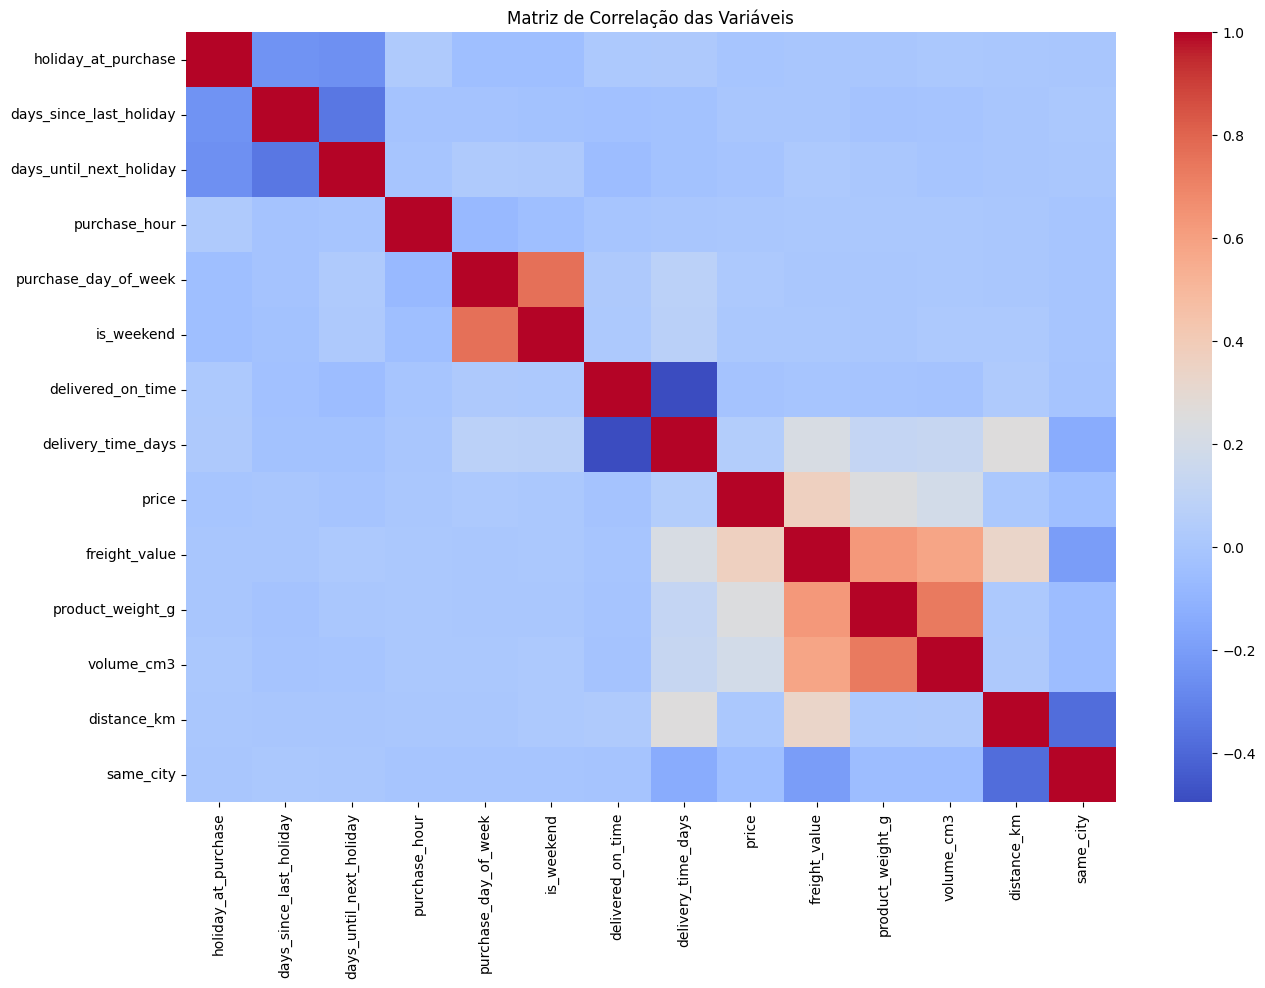

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlação das Variáveis')
plt.show()

In [6]:
# Verificando a correlação (agora ignorando colunas de texto/data)
correlacao = df.corr(numeric_only=True)
print(correlacao['delivery_time_days'].sort_values(ascending=False).head(20))

delivery_time_days         1.000000
distance_km                0.252284
freight_value              0.218740
volume_cm3                 0.130162
product_weight_g           0.123101
purchase_day_of_week       0.082317
is_weekend                 0.072852
price                      0.046499
holiday_at_purchase        0.019318
purchase_hour             -0.001271
days_since_last_holiday   -0.026585
days_until_next_holiday   -0.027954
same_city                 -0.135635
delivered_on_time         -0.496131
Name: delivery_time_days, dtype: float64


## Relacionando Variáveis
### 3 Variáveis com a maior correlação:
* `distance_km` ->                       0.252284
* `freight_value`  ->                     0.218740
* `seller_geolocation_lat`             ->                   0.193206

In [7]:
%pip install plotly
# importando as visualizações
import seaborn as sns
import plotly.express as px

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


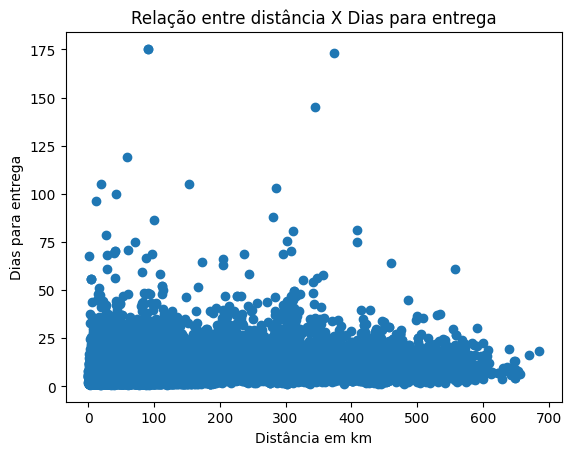

In [8]:
plt.scatter(df['distance_km'], df['delivery_time_days'])
plt.title('Relação entre distância X Dias para entrega')
plt.xlabel('Distância em km')
plt.ylabel('Dias para entrega')
plt.show()

In [9]:
px.scatter(df, x = 'distance_km', y = 'delivery_time_days', 
           trendline_color_override="red", trendline='ols')

## Distribuição do delivery_time_days 
### Utilizando histograma e boxplot

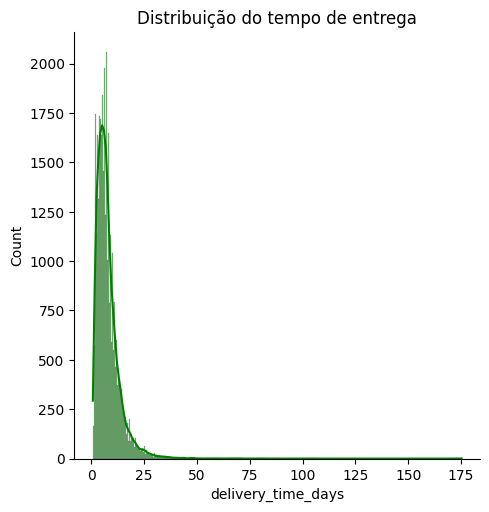

In [10]:
sns.displot(df['delivery_time_days'], kde=True, color='green')
plt.title('Distribuição do tempo de entrega')
plt.show()

Pode-se observar que o gráfico está assimétrico -> Influência desproporcional de valores altos: Valores muito grandes "puxam" a reta da regressão, prejudicando a precisão para a maioria dos dados.

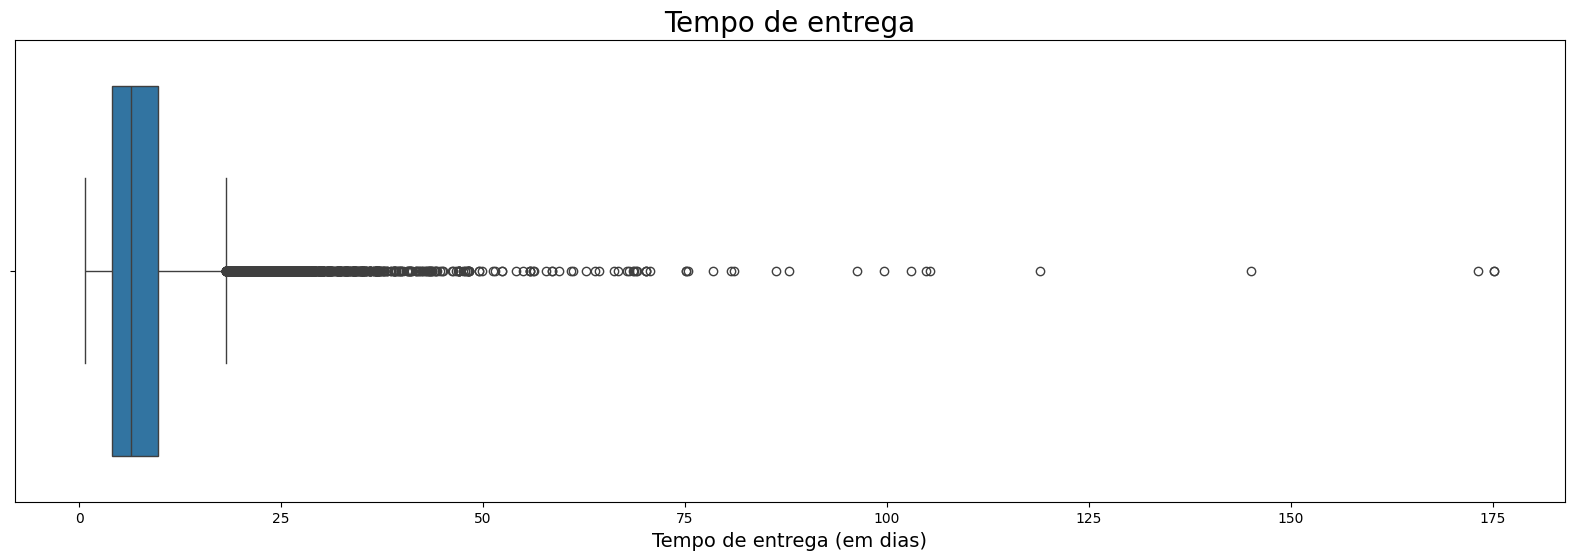

In [11]:
ax = sns.boxplot(x='delivery_time_days', data=df)

ax.figure.set_size_inches(20, 6)
ax.set_title('Tempo de entrega', fontsize=20)
ax.set_xlabel('Tempo de entrega (em dias)', fontsize=14)
plt.show()

## Analisando as variáveis independentes

In [12]:
df.columns

Index(['holiday_at_purchase', 'days_since_last_holiday',
       'days_until_next_holiday', 'purchase_hour', 'purchase_day_of_week',
       'is_weekend', 'delivered_on_time', 'delivery_time_days', 'price',
       'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km',
       'same_city'],
      dtype='str')

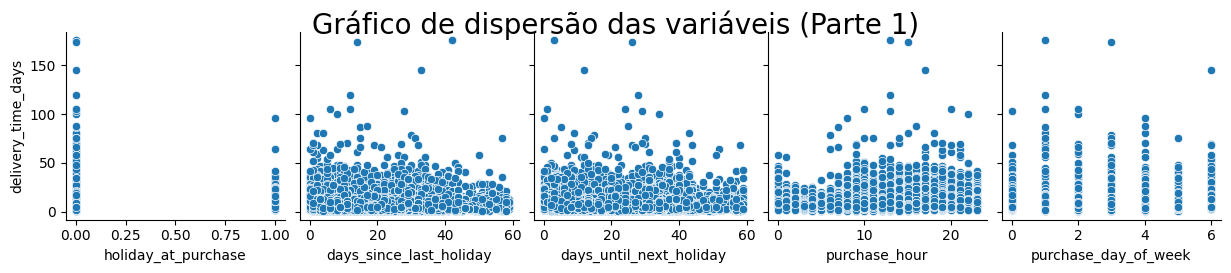

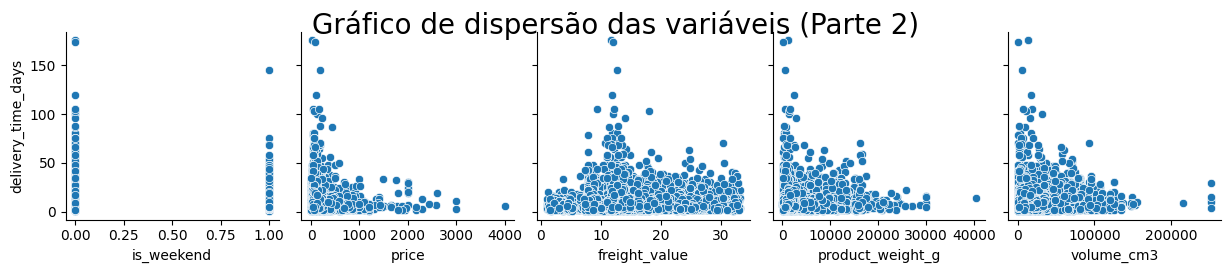

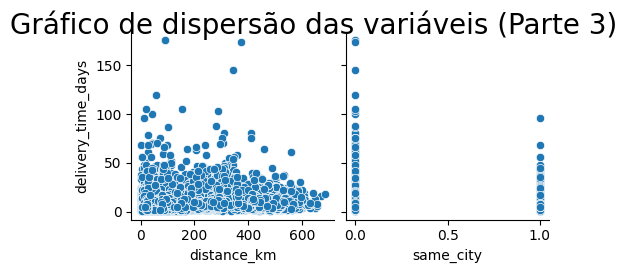

In [13]:
x_vars_list = ['holiday_at_purchase', 'days_since_last_holiday',
       'days_until_next_holiday', 'purchase_hour', 'purchase_day_of_week',
       'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city']

for i in range(0, len(x_vars_list), 5):
    ax = sns.pairplot(df, y_vars="delivery_time_days", x_vars=x_vars_list[i:i+5])
    ax.figure.suptitle(f'Gráfico de dispersão das variáveis (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

### Refazendo a lista: retiramos as variáveis binárias

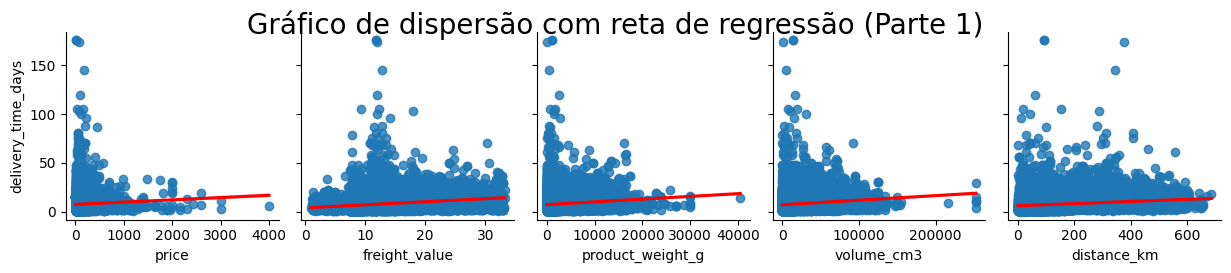

In [14]:
x_vars_list_reg = ['price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km']

for i in range(0, len(x_vars_list_reg), 5):
    ax = sns.pairplot(df, y_vars="delivery_time_days", x_vars=x_vars_list_reg[i:i+5],
                      kind='reg', plot_kws={'line_kws':{'color':'red'}})
    ax.figure.suptitle(f'Gráfico de dispersão com reta de regressão (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

## Aplicando transformação logarítmica

In [15]:
df.describe().round(2)

,holiday_at_purchase,days_since_last_holiday,days_until_next_holiday,purchase_hour,purchase_day_of_week,is_weekend,delivered_on_time,delivery_time_days,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city
count,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00
mean,0.03,19.17,20.45,14.71,2.89,0.24,0.94,7.82,91.97,12.02,1612.40,12874.94,148.36,0.14
std,0.17,13.34,13.65,5.33,1.88,0.43,0.24,6.12,122.81,4.30,2692.11,17076.20,140.85,0.35
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.78,1.20,0.98,0.00,352.00,0.08,0.00
25%,0.00,8.00,9.00,11.00,1.00,0.00,1.00,4.13,32.99,8.72,250.00,2601.00,28.87,0.00
50%,0.00,17.00,19.00,15.00,3.00,0.00,1.00,6.46,59.90,11.85,600.00,5832.00,93.67,0.00
75%,0.00,29.00,30.00,19.00,4.00,0.00,1.00,9.76,109.90,13.64,1550.00,16206.00,264.07,0.00
max,1.00,59.00,59.00,23.00,6.00,1.00,1.00,175.22,3999.90,33.22,40425.00,252402.00,685.46,1.00


In [16]:
cols = [
    'holiday_at_purchase', 'days_since_last_holiday',
    'days_until_next_holiday', 'purchase_hour', 'purchase_day_of_week',
    'is_weekend', 'delivery_time_days', 'price', 'freight_value',
    'product_weight_g', 'volume_cm3', 'distance_km', 'same_city'
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
holiday_at_purchase,33820.0,0.028031,0.165063,0.000,0.000,0.000,0.0000,1.000
days_since_last_holiday,33820.0,19.173980,13.338231,0.000,8.000,17.000,29.0000,59.000
days_until_next_holiday,33820.0,20.449468,13.645660,0.000,9.000,19.000,30.0000,59.000
purchase_hour,33820.0,14.708072,5.326621,0.000,11.000,15.000,19.0000,23.000
purchase_day_of_week,33820.0,2.890302,1.881817,0.000,1.000,3.000,4.0000,6.000
is_weekend,33820.0,0.243525,0.429215,0.000,0.000,0.000,0.0000,1.000
delivery_time_days,33820.0,7.816442,6.124319,0.781,4.128,6.456,9.7650,175.224
price,33820.0,91.973878,122.810337,1.200,32.990,59.900,109.9000,3999.900
freight_value,33820.0,12.018414,4.298559,0.980,8.720,11.850,13.6400,33.220
product_weight_g,33820.0,1612.396008,2692.113177,0.000,250.000,600.000,1550.0000,40425.000


Aplicando log1p para os que tiveram min = 0.00, para o Python não retornar erro ou valores -inf

In [17]:
# 1. Aplicação de log1p para quem tem MÍNIMO = 0 (evita -inf)
df['log_holiday_at_purchase'] = np.log1p(df['holiday_at_purchase'])
df['log_days_since_last_holiday'] = np.log1p(df['days_since_last_holiday'])
df['log_days_until_next_holiday'] = np.log1p(df['days_until_next_holiday'])
df['log_purchase_hour'] = np.log1p(df['purchase_hour'])
df['log_purchase_day_of_week'] = np.log1p(df['purchase_day_of_week'])
df['log_is_weekend'] = np.log1p(df['is_weekend'])
df['log_product_weight_g'] = np.log1p(df['product_weight_g'])
df['log_same_city'] = np.log1p(df['same_city'])

# 2. Aplicação de log puro para quem tem MÍNIMO > 0
df['log_delivery_time_days'] = np.log(df['delivery_time_days'])
df['log_price'] = np.log(df['price'])
df['log_freight_value'] = np.log(df['freight_value'])
df['log_volume_cm3'] = np.log(df['volume_cm3'])
df['log_distance_km'] = np.log(df['distance_km'])


In [18]:
df.head()

,holiday_at_purchase,days_since_last_holiday,days_until_next_holiday,purchase_hour,purchase_day_of_week,is_weekend,delivered_on_time,delivery_time_days,price,freight_value,...,log_purchase_hour,log_purchase_day_of_week,log_is_weekend,log_product_weight_g,log_same_city,log_delivery_time_days,log_price,log_freight_value,log_volume_cm3,log_distance_km
0,0,5,5,10,3,0,1,16.216,239.90,19.93,...,2.397895,1.386294,0.0,10.308986,0.0,2.785998,5.480222,2.992226,11.002100,6.376775
1,0,30,30,10,3,0,1,6.147,12.99,12.79,...,2.397895,1.386294,0.0,5.303305,0.0,1.815964,2.564180,2.548664,7.783224,5.673230
2,0,25,15,11,0,0,1,8.423,19.90,11.85,...,2.484907,0.000000,0.0,5.303305,0.0,2.130966,2.990720,2.472328,7.901007,6.183318
3,0,34,11,18,1,0,0,9.984,145.95,11.65,...,2.944439,0.693147,0.0,7.601402,0.0,2.300984,4.983264,2.455306,8.658693,3.969858
4,0,32,7,13,1,0,1,2.145,53.99,11.40,...,2.639057,0.693147,0.0,6.746412,0.0,0.763140,3.988799,2.433613,7.510431,3.501344


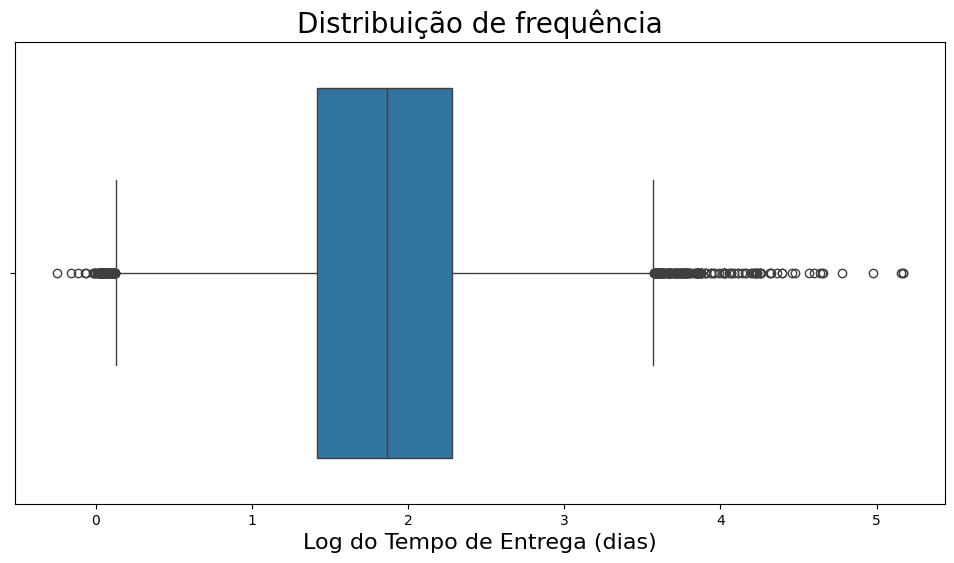

In [19]:
ax = sns.boxplot(x='log_delivery_time_days', data=df)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Tempo de Entrega (dias)', fontsize=16)
plt.show()

Diminuiu a assimetria

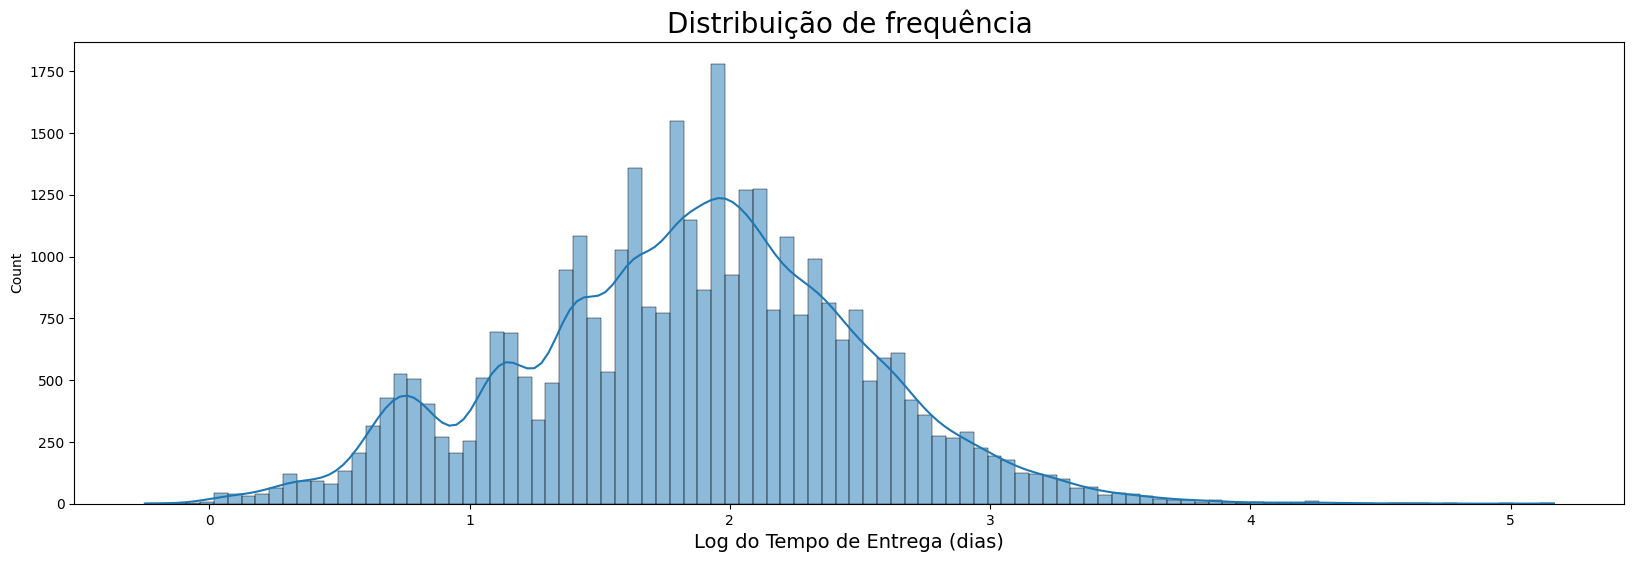

In [20]:
ax = sns.histplot(x='log_delivery_time_days', data=df, kde=True)
ax.figure.set_size_inches(20, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Tempo de Entrega (dias)', fontsize=14)
plt.show()

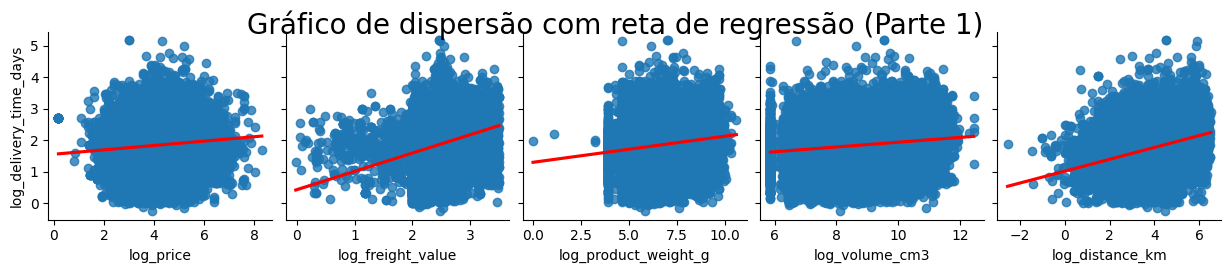

In [21]:
x_vars_list_reg = ['log_price', 'log_freight_value',
       'log_product_weight_g', 'log_volume_cm3', 'log_distance_km'
]

for i in range(0, len(x_vars_list_reg), 5):
    ax = sns.pairplot(df, y_vars="log_delivery_time_days", x_vars=x_vars_list_reg[i:i+5],
                      kind='reg', plot_kws={'line_kws':{'color':'red'}})
    ax.figure.suptitle(f'Gráfico de dispersão com reta de regressão (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

## Definição das variáveis X e y
* X = variáveis explicativas
* y = variável que queremos prever

In [22]:
# Variável dependente (o que queremos prever)
y = df['delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas)
X = df[['holiday_at_purchase', 'days_since_last_holiday',
    'days_until_next_holiday', 'purchase_hour', 'purchase_day_of_week',
    'is_weekend', 'price', 'freight_value',
    'product_weight_g', 'volume_cm3', 'distance_km', 'same_city']]

In [23]:
# Remove linhas com NaN/inf nas variaveis originais
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

Divisão em treino e teste

In [24]:
train_mask = date_col.loc[X.index] < split_date
test_mask = date_col.loc[X.index] >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()
print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 28706 amostras | Teste: 5114 amostras


In [25]:
# Resumo da proporcao de entregas no prazo e em atraso em cada parte do split temporal
def resumo_entregas(indices, nome_particao):
    base = df.loc[indices, 'delivered_on_time'].dropna()
    total = len(base)

    if total == 0:
        return {
            'Parte': nome_particao,
            'Total': 0,
            'Atraso (qtd)': 0,
            'Atraso (%)': 0.0,
            'No prazo (qtd)': 0,
            'No prazo (%)': 0.0,
        }

    atraso_qtd = int((base == 0).sum())
    no_prazo_qtd = int((base == 1).sum())

    return {
        'Parte': nome_particao,
        'Total': total,
        'Atraso (qtd)': atraso_qtd,
        'Atraso (%)': round((atraso_qtd / total) * 100, 2),
        'No prazo (qtd)': no_prazo_qtd,
        'No prazo (%)': round((no_prazo_qtd / total) * 100, 2),
    }

resumo_entregas = pd.DataFrame([
    resumo_entregas(X_train.index, 'Treino'),
    resumo_entregas(X_test.index, 'Teste'),
])

print(resumo_entregas.to_string(index=False))

 Parte  Total  Atraso (qtd)  Atraso (%)  No prazo (qtd)  No prazo (%)
Treino  28706          1425        4.96           27281         95.04
 Teste   5114           613       11.99            4501         88.01


Treinando o modelo

In [26]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 28706 entries, 0 to 33819
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   holiday_at_purchase      28706 non-null  int64  
 1   days_since_last_holiday  28706 non-null  int64  
 2   days_until_next_holiday  28706 non-null  int64  
 3   purchase_hour            28706 non-null  int64  
 4   purchase_day_of_week     28706 non-null  int64  
 5   is_weekend               28706 non-null  int64  
 6   price                    28706 non-null  float64
 7   freight_value            28706 non-null  float64
 8   product_weight_g         28706 non-null  int64  
 9   volume_cm3               28706 non-null  float64
 10  distance_km              28706 non-null  float64
 11  same_city                28706 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 2.8 MB


In [27]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Avaliação do modelo

In [28]:
# Realizar previsões
previsoes = modelo.predict(X_train)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_train, previsoes)}")

R² Score: 0.09928495230693701


In [29]:
# Realizar previsões
previsoes_test = modelo.predict(X_test)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_test, previsoes_test)}")

R² Score: -0.3270570307964369


In [30]:
# Variável dependente (o que queremos prever)
y_log = df['log_delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas + geolocalização linear)
X_log = df[['log_holiday_at_purchase', 'log_days_since_last_holiday',
    'log_days_until_next_holiday', 'log_purchase_hour', 'log_purchase_day_of_week',
    'log_is_weekend', 'log_price', 'log_freight_value',
    'log_product_weight_g', 'log_volume_cm3', 'log_distance_km', 'log_same_city']]

In [31]:
# Remove linhas com NaN/inf nas variaveis log
X_log = X_log.replace([np.inf, -np.inf], np.nan)
y_log = y_log.replace([np.inf, -np.inf], np.nan)
mask = X_log.notna().all(axis=1) & y_log.notna()
X_log = X_log.loc[mask]
y_log = y_log.loc[mask]

In [32]:
train_mask_log = date_col.loc[X_log.index] < split_date
test_mask_log = date_col.loc[X_log.index] >= split_date

X_train_log = X_log[train_mask_log].copy()
y_train_log = y_log[train_mask_log].copy()
X_test_log = X_log[test_mask_log].copy()
y_test_log = y_log[test_mask_log].copy()
print(f"Treino (log): {len(X_train_log)} amostras | Teste (log): {len(X_test_log)} amostras")

Treino (log): 28706 amostras | Teste (log): 5114 amostras


In [33]:
modelo = LinearRegression()
modelo.fit(X_train_log, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
# Realizar previsões
previsoes_log = modelo.predict(X_train_log)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_train_log, previsoes_log)}")

R² Score: 0.1986117667471322


In [35]:
# Realizar previsões
previsoes_log_test = modelo.predict(X_test_log)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_test_log, previsoes_log_test)}")

R² Score: -0.062282732503505356


In [36]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionar as colunas que você transformou em log
colunas_log = ['log_holiday_at_purchase', 'log_days_since_last_holiday',
    'log_days_until_next_holiday', 'log_purchase_hour', 'log_purchase_day_of_week',
    'log_is_weekend', 'log_price', 'log_freight_value',
    'log_product_weight_g', 'log_volume_cm3', 'log_distance_km', 'log_same_city']

# 2. Inicializar o Scaler
scaler = StandardScaler()

# 3. Ajustar no treino e transformar treino e teste
# Importante: O scaler retorna um array numpy, então reconvertemos para DataFrame para manter os nomes das colunas
X_train_scaled = X_train_log.copy()
X_test_scaled = X_test_log.copy()

X_train_scaled[colunas_log] = scaler.fit_transform(X_train_log[colunas_log])
X_test_scaled[colunas_log] = scaler.transform(X_test_log[colunas_log])

# 4. Treinar o modelo com os dados padronizados
modelo_final = LinearRegression()
modelo_final.fit(X_train_scaled, y_train_log)

# 5. Criar um DataFrame para ver a importância das variáveis
importancia = pd.DataFrame({
    'Variavel': X_train_scaled.columns,
    'Coeficiente': modelo_final.coef_
}).sort_values(by='Coeficiente', ascending=False)

print(importancia)

                       Variavel  Coeficiente
10              log_distance_km     0.219172
7             log_freight_value     0.126805
4      log_purchase_day_of_week     0.053879
5                log_is_weekend     0.049001
11                log_same_city     0.034565
9                log_volume_cm3     0.023593
1   log_days_since_last_holiday     0.015352
0       log_holiday_at_purchase     0.012502
3             log_purchase_hour     0.008326
8          log_product_weight_g    -0.000431
2   log_days_until_next_holiday    -0.024433
6                     log_price    -0.027028


* `log_distance_km (0.219)` e `log_freight_value (0.126)` são, de longe, os fatores mais cruciais que puxam o tempo de entrega para cima. Isso faz total sentido logístico: maior distância = frete mais caro = demorará mais dias para chegar.
* `log_price (-0.026)`: Ele mostrou um impacto invertido. Indica que compras de valores maiores (price mais alto) tendem a demorar um pouco menos (talvez por pagarem fretes expressos, envios em transportadoras melhores para produtos premiums, etc).

# Importância das variáveis

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_25460\2600342382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variavel', data=importancia, palette='RdYlGn')


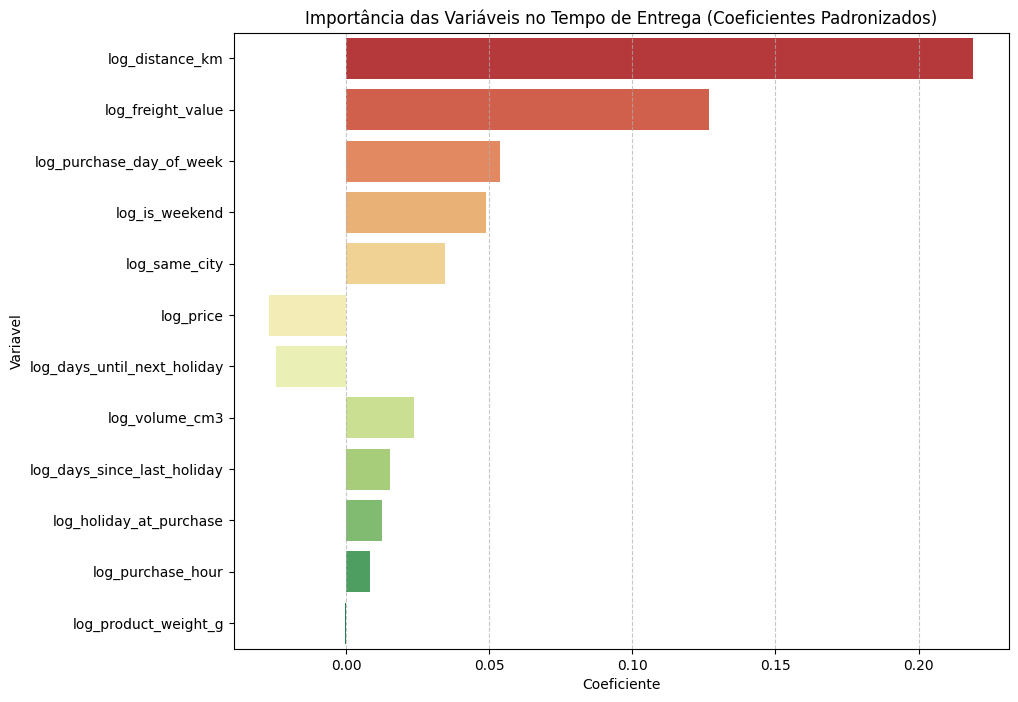

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando o gráfico
plt.figure(figsize=(10, 8))
# Ordenando pela magnitude (valor absoluto) para mostrar o que mais importa
importancia = importancia.reindex(importancia.Coeficiente.abs().sort_values(ascending=False).index)

sns.barplot(x='Coeficiente', y='Variavel', data=importancia, palette='RdYlGn')
plt.title('Importância das Variáveis no Tempo de Entrega (Coeficientes Padronizados)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecione apenas as colunas numéricas que você usou no modelo
X_vif = X_log.select_dtypes(include=[np.number])
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data)

                        feature         VIF
0       log_holiday_at_purchase    1.791740
1   log_days_since_last_holiday   11.679564
2   log_days_until_next_holiday   12.969863
3             log_purchase_hour   19.228859
4      log_purchase_day_of_week    7.987096
5                log_is_weekend    2.136514
6                     log_price   31.422074
7             log_freight_value  102.089024
8          log_product_weight_g   82.196050
9                log_volume_cm3   96.815685
10              log_distance_km   21.693653
11                log_same_city    1.708845


"O diagnóstico de multicolinearidade via VIF (Variance Inflation Factor) revelou valores acima de 10 para diversas variáveis, com destaque para o custo de frete (`log_freight_value`) e volume do produto (`log_volume_cm3`), que atingiram VIF de aproximadamente 100 e 95 respectivamente. Isso indica uma redundância informacional que instabiliza os coeficientes. Para garantir a interpretabilidade do modelo e a validade estatística dos coeficientes, optou-se pela exclusão das variáveis redundantes, mantendo-se apenas os preditores de maior relevância teórica e menor correlação entre si."

* `log_freight_value (100.5)`, `log_volume_cm3 (94.7)` e `log_product_weight_g (81.9)`.
Por que acontece: Como as transportadoras calculam o valor do frete? Baseado no peso, no volume (cubagem) e na distância. Colocar todas essas variáveis juntas cria um loop de redundância. O modelo se "confunde" ao tentar atribuir impacto isolado ao frete ou ao repassar o impacto para o volume, quando na essência representam a mesma carga estrutural do cálculo. Também notamos VIFs elevados para `log_price (31.3)` e `log_distance_km (21.5)`.

Ação: deixar somente o frete, ou o frete e mais um dos dois.

# Refazendo os modelos

In [39]:
from statsmodels.tools.tools import add_constant

# Removendo colunas com extrema colinearidade e redundância baseada no VIF
colunas_remover_vif = [
    'log_volume_cm3',        # Redundante para o calculo de frete
    'log_product_weight_g',  # Redundante para o calculo de frete
    'log_purchase_hour'      # VIF alto e pouco impacto logístico em DIAS
]

X_log_v2 = X_log.drop(columns=colunas_remover_vif)

# Calculando o VIF novamente (agora adicionando a constante, muito importante pro VIF correto)
X_vif_v2 = add_constant(X_log_v2.select_dtypes(include=[np.number]))
vif_data_v2 = pd.DataFrame()
vif_data_v2["feature"] = X_vif_v2.columns
vif_data_v2["VIF"] = [variance_inflation_factor(X_vif_v2.values, i) for i in range(len(X_vif_v2.columns))]
print(vif_data_v2.sort_values(by='VIF', ascending=False))

                       feature         VIF
0                        const  106.617625
1      log_holiday_at_purchase    2.005359
8              log_distance_km    1.773837
5               log_is_weekend    1.623948
4     log_purchase_day_of_week    1.623035
9                log_same_city    1.591083
3  log_days_until_next_holiday    1.512427
7            log_freight_value    1.474352
2  log_days_since_last_holiday    1.468370
6                    log_price    1.282188


In [40]:
# Retreinando o modelo com as variáveis filtradas
X_train_v2 = X_train_log.drop(columns=colunas_remover_vif)
X_test_v2 = X_test_log.drop(columns=colunas_remover_vif)

modelo_v2 = LinearRegression()
modelo_v2.fit(X_train_v2, y_train_log)

previsoes_train_v2 = modelo_v2.predict(X_train_v2)
previsoes_test_v2 = modelo_v2.predict(X_test_v2)

print(f"R² Train: {metrics.r2_score(y_train_log, previsoes_train_v2):.4f}")
print(f"R² Test:  {metrics.r2_score(y_test_log, previsoes_test_v2):.4f}")

R² Train: 0.1975
R² Test:  -0.0651


In [41]:
# Vamos dar uma olhada num modelo de árvore, já que a regressão linear sofre muito com outliers e relações não perfeitamente lineares
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10, n_jobs=-1)
modelo_rf.fit(X_train_v2, y_train_log)

previsoes_train_rf = modelo_rf.predict(X_train_v2)
previsoes_test_rf = modelo_rf.predict(X_test_v2)

print(f"Random Forest - R² Train: {metrics.r2_score(y_train_log, previsoes_train_rf):.4f}")
print(f"Random Forest - R² Test:  {metrics.r2_score(y_test_log, previsoes_test_rf):.4f}")

Random Forest - R² Train: 0.4017
Random Forest - R² Test:  0.0096


### Conclusões pós-tratamento de Colinearidade (VIF) e Teste com Random Forest:

**1. O problema da Multicolinearidade resolvido:**
A remoção de `log_volume_cm3`, `log_product_weight_g` e `log_purchase_hour` reduziu todos os VIFs para abaixo de 2. Agora temos **certeza** de que cada variável tem seu peso interpretativo na Regressão, sem que o modelo divida artificialmente a importância entre variáveis redundantes.

**2. O que os resultados do R² nos dizem (Treino vs Teste)?**
Tivemos um Train R² próximo a **0.20** na Regressão e **0.40** na Random Forest. Porém, em ambos os casos, ocorreu uma grave estagnação no teste (onde caíram para perto de **0.02** e **0.006**).
Esse abismo entre treino e teste no momento em que fazemos a quebra por tempo (Julho/2018) aponta fortemente para um **Data Drift (Mudança no Comportamento dos Dados)** no mundo real:

* **Mudança na Tabela de Fretes / Logística:** Após o primeiro semestre de 2018 (marcado por eventos reais como a greve dos caminhoneiros do final de Maio de 2018), os Correios e o sistema logístico brasileiro sofreram reajustes de tarifas, prazos e rotas. As regras estabelecidas pelo modelo no Treino (antes da greve/mudança) deixaram de se aplicar aos dados de Teste (pós-evento).
* **Random Forest Sobreajustada:** Embora a árvore seja melhor para cenários não lineares, no mundo do "tempo" o Random Forest tende a sofrer muito quando as novas previsões fogem da escala de valores que ele encontrava no treino e os hiperparâmetros não estão 100% afinados para evitar *overfitting* (decora as regras antigas, mas não sabe generalizar para o contexto pós Julho/2018).

**Próximos Passos recomendados:**
Apesar da limpeza minuciosa, modelagens temporais sofrem duramente com eventos macroeconômicos. É sugerido incluir flag de feriados ou eventos logísticos catastróficos para esse período ou testar o XGBoost, que costuma apresentar capacidade maior de generalização por penalizar árvores que se aprofundam demais nos padrões antigos.